# Segmentation of Cave Paintings using SAM3

[Segment Anything Model 3 (SAM3)](https://github.com/facebookresearch/sam3/tree/main) is used to evaluate the performance of a foundation model for this specific task. 

This notebook is inspired from :
https://github.com/facebookresearch/sam3/blob/main/examples/sam3_image_predictor_example.ipynb

In [ ]:
import os

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

/usr/users/x_chaos_meteo/arfib_lou/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/usr/users/x_chaos_meteo/arfib_lou/.conda/envs/sam3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

print(os.uname())
print(torch.cuda.is_available())

## Build model

In [5]:
model = build_sam3_image_model()

## Hands

A probability threshold of 0.05 is chosen for the detection.

Different text prompts are considered :

- "cave painting" : All the cave wall is detected,
- "hand" : nothing,
- "art" : all the cave wall,
- "negative hand" : nothing,
- "main négative" : nothing,
- "main négative paléolithique" : nothing,
- "negative hand paleolithic" : nothing,
- "art pariétal" : nothing,
- "parietal art" : three random objects that aren't the hands.

In [6]:
image_path = 'prompt_dataset/Gargas_-_Grande_Paroi_-_Panneau_6.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.05)
inference_state = processor.set_image(image)

found 3 object(s)


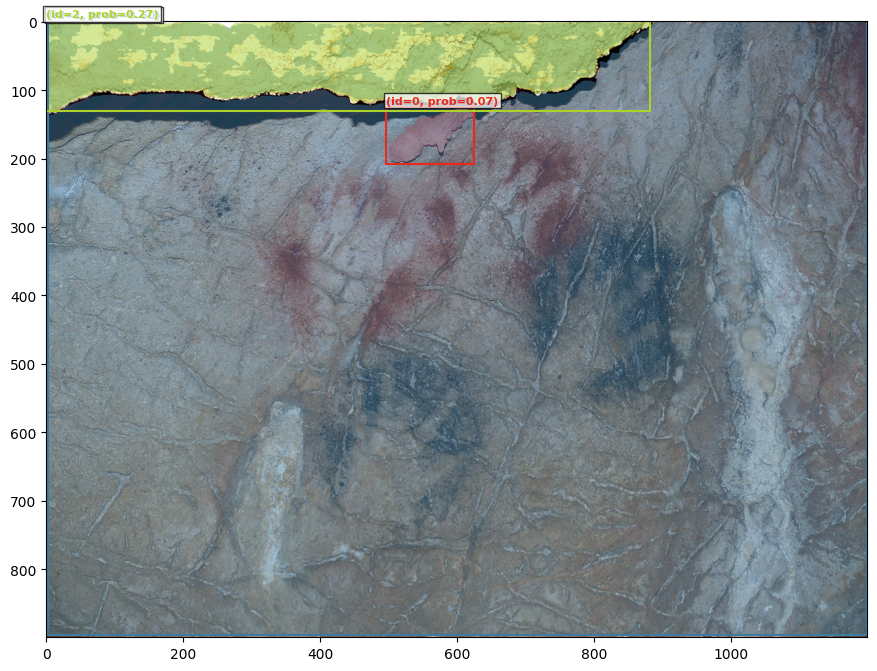

In [7]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="parietal art")
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

## Gargas 2

- "cave painting" : all the cave wall,
- "hand" : nothing
- "art" : all the cave wall,
- "negative hand" : nothing,
- "main négative" : nothing
- "main négative paléolithique" : nothing
- "negative hand paleolithic" : all the cave wall
- "art pariétal" : nothing
- "parietal art" : all the cave wall. ==> The model seems to understand that the picture is one of a cave wall with parietal art.

In [8]:
image_path = 'prompt_dataset/Gargas_-_Sanctuaire_des_Mains_Interieur.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.05)
inference_state = processor.set_image(image)

found 2 object(s)


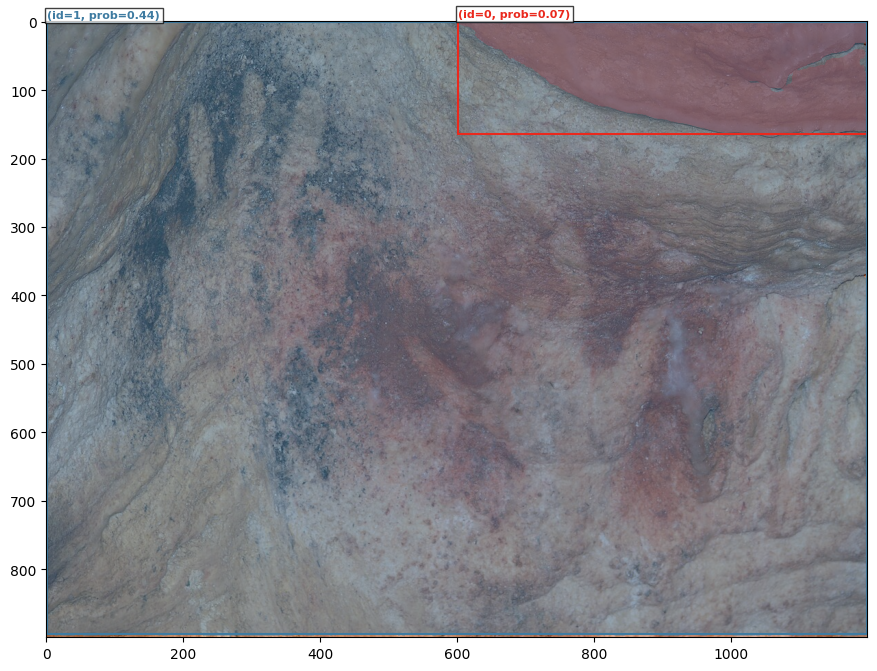

In [9]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="parietal art")
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

Conclusion : this model doesn't succeed at segmenting hands !

## Horses, bisons and aurochs

### Lascaux 1 :

threshold = 0.05

- "horse" : nothing,
- "cheval" : 29 objects. After increasing the probability threshold to 0.1 (to remove objects of very low probability), 9 objects are still found. The bigger horse and the auroch are found, the smaller horses below are segmented under one mask, some are missing and the segmentation isn't clean.
- "bison" : nothing.
- "art pariétal": nothing.
- "parietal art" : Most of the cave wall is segmented, but with a big probability (0.73).
- "cave painting" : 2 outputs segment approximatly all the paintings, but the different paintings aren't detected and the segmentation is imprecise.

In [10]:
image_path = 'prompt_dataset/Lascaux_007.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.05)
inference_state = processor.set_image(image)

"Cave painting" prompt :

found 2 object(s)


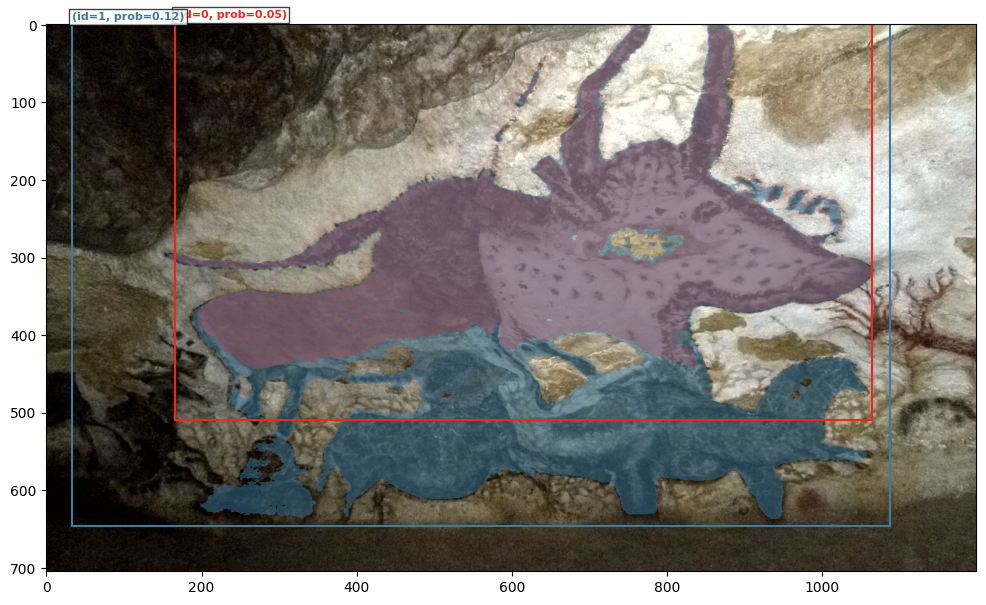

In [11]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="cave painting")
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

"cheval" prompt :

found 9 object(s)


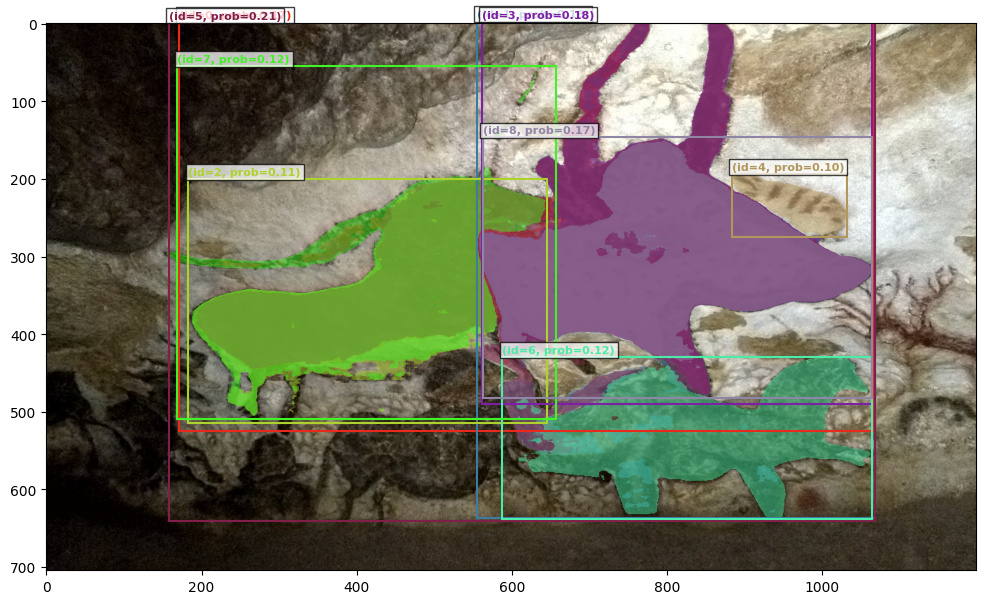

In [12]:
image_path = 'prompt_dataset/Lascaux_007.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.1)
inference_state = processor.set_image(image)

processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="cheval")
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

"Parietal art" prompt :

found 1 object(s)


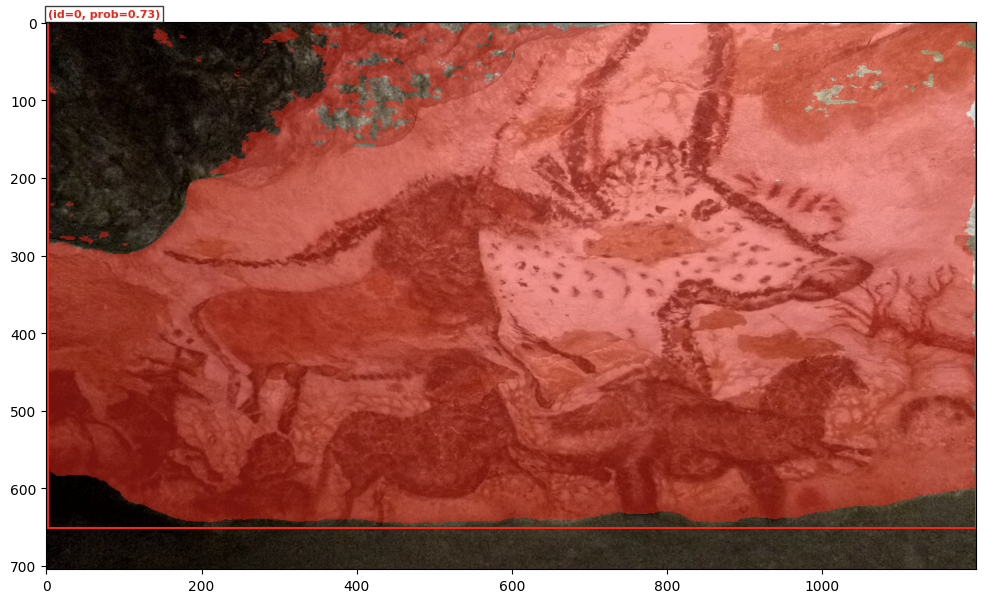

In [13]:
image_path = 'prompt_dataset/Lascaux_007.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="parietal art")
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

### Lascaux 2 (Lascaux_020.jpg) :

threshold = 0.05

- "horse": Perfect ! All the paintings are segmented and the segmentation is very clean.
- "cheval": Very good, all the horses and only the horses are found. The results are given with less confidence (prabability of about 0.15).
- "bison": same result as "cheval".
- "art pariétal": nothing.
- "parietal art": A lot of objects are found but the segmentation isn't clean. With a probability threshold of 0.3: the four horses are found as well as the auroch. All the cave wall is also segmented, with the highest probablity.
- "cave painting": A lot of paintings are found with a high probablity.
- "auroch": nothing.

In [30]:
image_path = 'prompt_dataset/Lascaux_020.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.3)
inference_state = processor.set_image(image)

found 14 object(s)


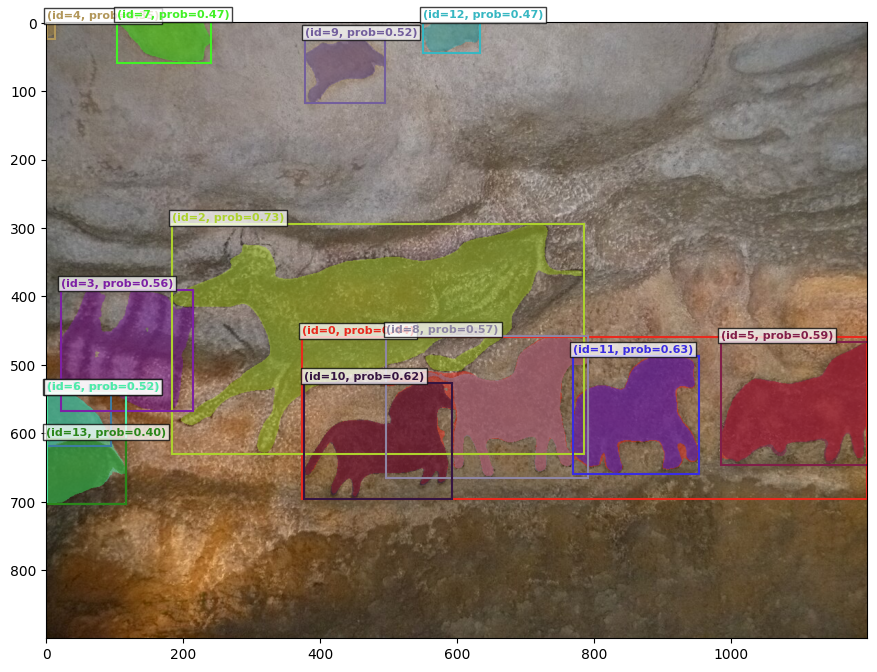

In [31]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="cave painting")
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

Résultats avec horse :

found 15 object(s)


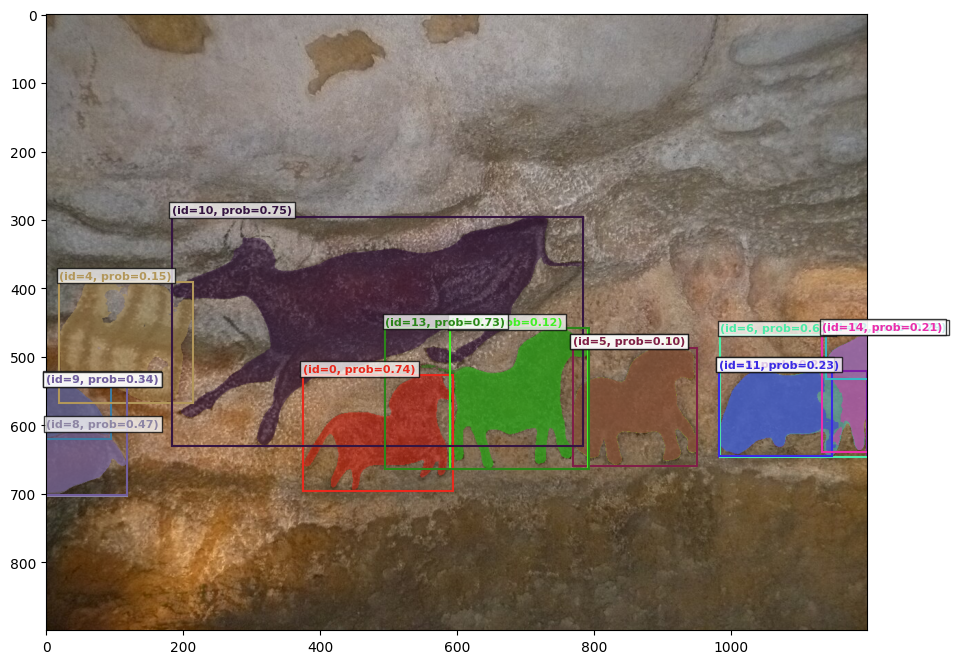

In [17]:
image_path = 'prompt_dataset/Lascaux_020.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.1)
inference_state = processor.set_image(image)
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="horse")
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

Résultats avec parietal art

found 6 object(s)


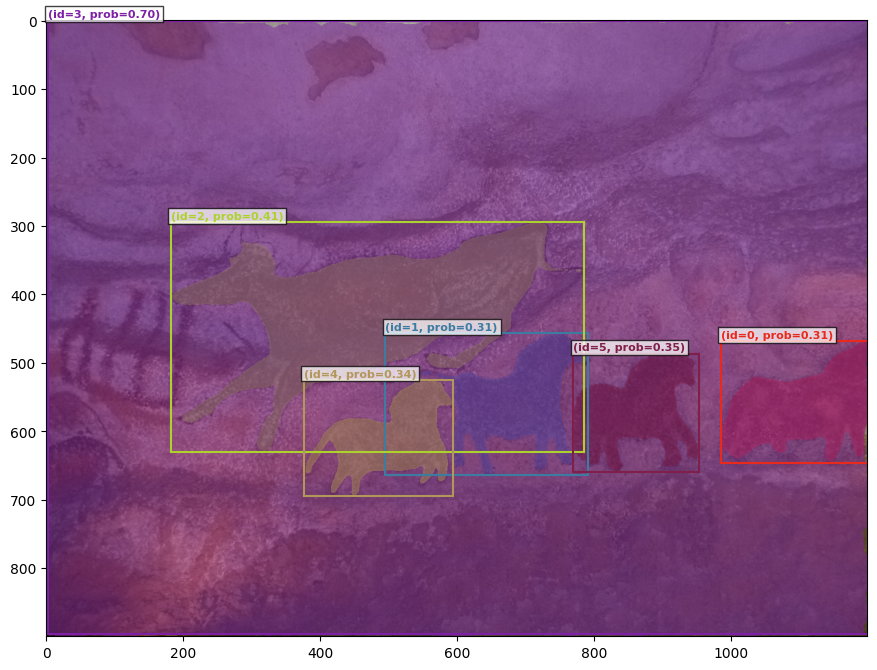

In [21]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="parietal art")
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)